In [2]:
# Kai Gandingco
# COE 311K
# 26 February 2026
# Homework 4

import numpy as np
import matplotlib.pyplot as plt

# Function for Absolute Error
def absErr(newIter, oldIter):
    return np.linalg.norm(newIter - oldIter, ord=np.inf)

In [3]:
# Jacobi Function
def jacobi(A, b, x0, tolerance, maxIterations):
    n = len(b)
    x = x0.copy()
    absErrors = []
    
    for k in range (maxIterations):
        xNew = np.zeros_like(x)
        for i in range(n): 
            s = sum(A[i][j] * x[j] for j in range(n) if j!= i)
            xNew[i] = (b[i] - s) / A[i][i]
            
        absErrors.append(absErr(xNew, x))
            
        if absErrors[-1] < tolerance:
            return xNew, k + 1, absErrors
        
        x = xNew
    return x, maxIterations, absErrors

# Gauss-Seidel Function
def gauss_seidel(A, b, x0, tolerance, maxIterations):
    n = len(b)
    x = x0.copy()
    absErrors = []
    
    for k in range (maxIterations):
        xNew = x.copy()
        for i in range(n):
            s1 = sum(A[i][j] * xNew[j] for j in range (i))
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n))
            xNew[i] = (b[i] - s1 -s2) / A[i][i]
            
        absErrors.append(absErr(xNew, x))
            
        if absErrors[-1] < tolerance:
            return xNew, k + 1, absErrors
        
        x = xNew
    return x, maxIterations, absErrors

Tolerance: 0.001
Jacobi iterations: 4
Gauss-Seidel iterations: 4



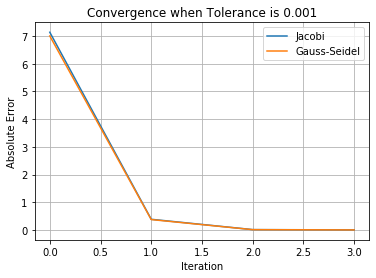

Tolerance: 1e-06
Jacobi iterations: 7
Gauss-Seidel iterations: 5



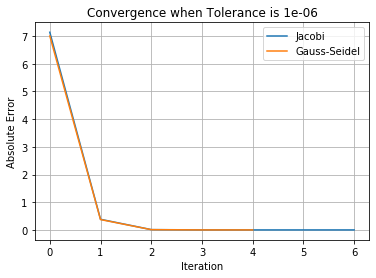

Tolerance: 1e-09
Jacobi iterations: 9
Gauss-Seidel iterations: 7



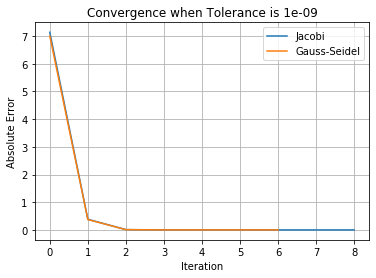

In [4]:
A = np.array([[  3, -0.1, -0.2],
              [0.1,    7, -0.3],
              [0.3, -0.2,   10]], dtype=float)
b = np.array([7.85, -19.3, 71.4], dtype=float)
x0 = np.zeros_like(b)
tolerances = np.array([1e-3, 1e-6, 1e-9])
maxIterations = 100

for tol in tolerances:
    jacobi_x, jacobi_iter, jacobi_err = jacobi(A, b, x0, tol, maxIterations)
    gs_x, gs_iter, gs_err = gauss_seidel(A, b, x0, tol, maxIterations)
    
    # Comparing number of iterations
    print(f"Tolerance: {tol}")
    print(f"Jacobi iterations: {jacobi_iter}")
    print(f"Gauss-Seidel iterations: {gs_iter}\n")
    
    # Plotting absolute error between iterations
    plt.figure()
    plt.plot(jacobi_err, label="Jacobi")
    plt.plot(gs_err, label="Gauss-Seidel")
    plt.xlabel("Iteration")
    plt.ylabel("Absolute Error")
    plt.title(f"Convergence when Tolerance is {tol}")
    plt.legend()
    plt.grid()
    plt.show()

In [5]:
"""
A smaller tolerance requires a greater number of iterations needed
for convergence, hence why it took 9 and 7 iterations for convergence
with a tolerance of 1e-9, but it took only 4 iterations for
convergence with a tolerance of 1e-3.
"""

'\nA smaller tolerance requires a greater number of iterations needed\nfor convergence, hence why it took 9 and 7 iterations for convergence\nwith a tolerance of 1e-9, but it took only 4 iterations for\nconvergence with a tolerance of 1e-3.\n'